# 07 — Stage 6: Mechanistic Synthesis

Integrates the three independent analyses into one regulatory circuit:
- **pySCENIC** (Stage 3a) — 15 T-FAP TF regulons consistent across Harvey 2019 and Cherief 2023
- **CellRank** (Stage 4) — 119-gene overlap between T-FAP regulon targets and T-FAP lineage-driver genes
- **LIANA** (Stage 5) — differential ligand-receptor signalling, innervated vs. denervated

Two questions this notebook answers with data (not just literature assertion):
1. Which of the 15 T-FAP regulons contribute most of the 119 CellRank driver genes?
2. Are any of the headline LIANA receptor genes (Pdgfra, Nrp1/2, Fzd4, etc.) themselves transcriptional targets of the T-FAP TF program — i.e. is there a feedback loop between the fibrotic TF program and the receptors for the signals that regulate it?

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

ROOT = Path('../..')
DATA_PS = ROOT / 'data' / 'pyscenic'
DATA_LI = ROOT / 'data' / 'liana'
DATA_CR = ROOT / 'data' / 'cellrank'
OUT_DATA = ROOT / 'data' / 'mechanistic_synthesis'
OUT_FIG = ROOT / 'figures' / 'mechanistic_synthesis'
OUT_DATA.mkdir(exist_ok=True)
OUT_FIG.mkdir(exist_ok=True)

## 1. Load the 15 consistent T-FAP regulons and assign upstream signal family

Family assignment (AP-1 / KLF / NF-κB-inflammatory / Other) follows the grouping already established in Stage 3a (`docs/progress.md`). The upstream-family labels (TGFβ/PDGF→MEK-ERK, mechanotransduction, TNF/IL-1/macrophage-Notch) are literature-bridged, not re-derived here — they are the biological context connecting each TF family to known signalling inputs.

In [2]:
shared = pd.read_csv(DATA_PS / 'shared_diff_regulons.csv')
shared['TF'] = shared['regulon'].str.replace(r'\(\+\)$', '', regex=True)
shared['mean_score'] = shared[['harvey_score', 'cherief_score']].mean(axis=1)

FAMILY = {
    'Fos': 'AP-1', 'Fosb': 'AP-1', 'Jun': 'AP-1', 'Junb': 'AP-1', 'Jund': 'AP-1', 'Atf3': 'AP-1',
    'Klf6': 'KLF', 'Klf9': 'KLF',
    'Nfkb1': 'NF-kB/Inflammatory', 'Irf1': 'NF-kB/Inflammatory', 'Egr1': 'NF-kB/Inflammatory', 'Cebpd': 'NF-kB/Inflammatory',
    'Pbx1': 'Other', 'Prdm16': 'Other', 'Zfp369': 'Other',
}
UPSTREAM = {
    'AP-1': 'TGFb / PDGF -> MEK-ERK',
    'KLF': 'Mechanotransduction / TGFb',
    'NF-kB/Inflammatory': 'TNF / IL-1 / Macrophage-Notch',
    'Other': 'Unresolved',
}
shared['family'] = shared['TF'].map(FAMILY)
tfs = shared['TF'].tolist()
shared[['TF', 'family', 'harvey_score', 'cherief_score']]

,TF,family,harvey_score,cherief_score
0,Cebpd,NF-kB/Inflammatory,20.779316,29.314266
1,Egr1,NF-kB/Inflammatory,20.603586,25.893581
2,Irf1,NF-kB/Inflammatory,20.546682,20.834347
3,Jund,AP-1,18.148964,28.431025
4,Fosb,AP-1,17.838593,26.718578
5,Junb,AP-1,17.365800,27.267511
6,Jun,AP-1,16.775726,26.297634
7,Nfkb1,NF-kB/Inflammatory,15.078421,21.235260
8,Fos,AP-1,14.255134,17.516514
9,Atf3,AP-1,11.003265,25.695847


## 2. Per-TF target gene sets from the GRNBoost2 + cisTarget regulons

The raw GRNBoost2 adjacency tables live only on the HPC scratch space (`pyscenic_03_grn.sh` output), not in this repo. The post-cisTarget-pruned `TargetGenes` column in `*_regulons.csv` is the motif-supported subset of those edges and is what's available locally — used here instead.

**Caveat:** target *gene identity* is much less consistent across datasets than target *TF activity* (see cross-dataset intersection column below). This is expected — co-expression network edges depend on which genes are variable/detected in each dataset — and is itself informative: it means the injury/denervation TF program is a conserved *hub*, but its *wiring* is context-dependent.

In [3]:
def load_targets(path):
    df = pd.read_csv(path, header=[0, 1], index_col=[0, 1])
    tg = df[('Enrichment', 'TargetGenes')]
    out = {}
    for tf in tfs:
        if tf not in df.index.get_level_values(0):
            out[tf] = set()
            continue
        rows = tg.loc[tf]
        rows = [rows] if isinstance(rows, str) else rows.tolist()
        genes = set()
        for r in rows:
            for gene, _weight in ast.literal_eval(r):
                genes.add(gene)
        out[tf] = genes
    return out

harvey_targets = load_targets(DATA_PS / 'harvey_regulons.csv')
cherief_targets = load_targets(DATA_PS / 'cherief_regulons.csv')
union_targets = {tf: harvey_targets[tf] | cherief_targets[tf] for tf in tfs}
cross_targets = {tf: harvey_targets[tf] & cherief_targets[tf] for tf in tfs}

shared['n_union_targets'] = shared['TF'].map(lambda tf: len(union_targets[tf]))
shared['n_cross_dataset_targets'] = shared['TF'].map(lambda tf: len(cross_targets[tf]))
shared[['TF', 'n_union_targets', 'n_cross_dataset_targets']].sort_values('n_cross_dataset_targets', ascending=False)

,TF,n_union_targets,n_cross_dataset_targets
7,Nfkb1,469,38
5,Junb,413,30
1,Egr1,903,21
10,Klf9,551,17
4,Fosb,603,10
2,Irf1,593,6
9,Atf3,324,6
13,Klf6,373,3
3,Jund,228,2
8,Fos,99,1


## 3. Do LIANA's headline receptor genes sit inside the T-FAP TF target sets?

Using the nine innervated-favoured and five denervated-favoured headline signal→receptor pairs already identified in Stage 5 (`docs/progress.md`), check whether the receptor gene itself is a target of one of the 15 T-FAP regulons. A hit means the T-FAP TF program doesn't just respond to these signals — it also transcriptionally shapes the cell's capacity to receive them (a candidate feedback/feed-forward loop), which is a stronger, data-supported claim than a purely literature-bridged one.

**Caveat:** this GRN was built only within the PDGFRα+ TSPC/T-FAP compartment, and `Pdgfra` is the marker gene defining that compartment — so its broad "target" status across many TFs may partly reflect uniformly high expression rather than TF-specific regulation. Treat single-TF hits (e.g. Fzd4→Irf1) as more specific than the six-TF Pdgfra hit.

In [4]:
innervated_signals = {
    'Efna1->Epha3': ['Epha3'], 'Sema4a->Plxnd1': ['Plxnd1'], 'Bmp3->Bmpr1b': ['Bmpr1b'],
    'Sema3d->Nrp/Plxna': ['Nrp1', 'Nrp2', 'Plxna2'], 'Wnt5a->Fzd4': ['Fzd4'],
    'Sema3c->Nrp2_Plxna1 (at TSPC)': ['Nrp2', 'Plxna1'], 'Pdgfc->Pdgfra': ['Pdgfra'],
    'Tgfb1/3->Itgb3': ['Itgb3'], 'Bdnf/Ngf->Erbb2': ['Erbb2'],
}
denervated_signals = {
    'Sema3f->Nrp2_Plxna1': ['Nrp2', 'Plxna1'], 'Tnf->Notch1': ['Notch1'],
    'Sema3c->Nrp1_Nrp2_Plxnd1 (at T-FAP)': ['Nrp1', 'Nrp2', 'Plxnd1'],
    'Rtn4->Rtn4rl1': ['Rtn4rl1'], 'Lama4/Lamb1->Itga9_Itgb1': ['Itga9', 'Itgb1'],
}

def receptor_feedback_table(sig_dict, direction):
    rows = []
    for sig, genes in sig_dict.items():
        for g in genes:
            hit = [tf for tf in tfs if g in union_targets[tf]]
            rows.append({'direction': direction, 'signal': sig, 'receptor_gene': g,
                         'regulated_by_TFAP_TF': ', '.join(hit) if hit else ''})
    return pd.DataFrame(rows)

feedback = pd.concat([
    receptor_feedback_table(innervated_signals, 'stronger_innervated'),
    receptor_feedback_table(denervated_signals, 'stronger_denervated'),
], ignore_index=True)
feedback.to_csv(OUT_DATA / 'liana_receptor_tf_feedback.csv', index=False)
feedback[feedback['regulated_by_TFAP_TF'] != '']

,direction,signal,receptor_gene,regulated_by_TFAP_TF
3,stronger_innervated,Sema3d->Nrp/Plxna,Nrp1,Egr1
4,stronger_innervated,Sema3d->Nrp/Plxna,Nrp2,"Egr1, Klf9"
5,stronger_innervated,Sema3d->Nrp/Plxna,Plxna2,Prdm16
6,stronger_innervated,Wnt5a->Fzd4,Fzd4,Irf1
7,stronger_innervated,Sema3c->Nrp2_Plxna1 (at TSPC),Nrp2,"Egr1, Klf9"
9,stronger_innervated,Pdgfc->Pdgfra,Pdgfra,"Egr1, Irf1, Jund, Fosb, Fos, Klf9"
12,stronger_denervated,Sema3f->Nrp2_Plxna1,Nrp2,"Egr1, Klf9"
15,stronger_denervated,Sema3c->Nrp1_Nrp2_Plxnd1 (at T-FAP),Nrp1,Egr1
16,stronger_denervated,Sema3c->Nrp1_Nrp2_Plxnd1 (at T-FAP),Nrp2,"Egr1, Klf9"


## 4. CellRank T-FAP driver genes per TF (Stage 4 overlap, re-summarised)

`data/cellrank/pyscenic_cellrank_tfap_overlap.csv` already lists, for each of the 119 overlap genes, which T-FAP regulon(s) target it. This section just re-aggregates that by TF to see which regulons actually anchor the CellRank-defined T-FAP fate program, versus which are differentially active (Section 1) but contribute few or no fate-driver targets.

In [5]:
overlap = pd.read_csv(DATA_CR / 'pyscenic_cellrank_tfap_overlap.csv')
overlap['tf_list'] = overlap['regulons'].str.replace(r'\(\+\)', '', regex=True).str.split(', ')
exploded = overlap.explode('tf_list')
driver_counts = exploded.groupby('tf_list').size()
shared['n_cellrank_drivers'] = shared['TF'].map(lambda tf: int(driver_counts.get(tf, 0)))

def top_drivers(tf, n=3):
    sub = exploded[exploded['tf_list'] == tf].copy()
    if sub.empty:
        return ''
    sub['abs_corr'] = sub[['T-FAP_1_corr', 'T-FAP_2_corr']].abs().max(axis=1)
    return ', '.join(sub.sort_values('abs_corr', ascending=False)['gene'].head(n))

shared['top_cellrank_drivers'] = shared['TF'].map(top_drivers)
shared[['TF', 'family', 'n_cellrank_drivers', 'top_cellrank_drivers']].sort_values('n_cellrank_drivers', ascending=False)

,TF,family,n_cellrank_drivers,top_cellrank_drivers
5,Junb,AP-1,35,"Gdf10, Angptl4, Il6"
3,Jund,AP-1,31,"Selenop, Serpina3n, Cst3"
10,Klf9,KLF,28,"Gdf10, Icam1, Nfib"
7,Nfkb1,NF-kB/Inflammatory,20,"Ptx3, Cebpb, Fosb"
9,Atf3,AP-1,16,"Junb, Cebpd, Fosb"
13,Klf6,KLF,14,"Slc16a1, Zfp36l1, Socs3"
1,Egr1,NF-kB/Inflammatory,14,"Steap4, Id2, Pltp"
4,Fosb,AP-1,12,"Sfrp1, Emb, Sgk1"
6,Jun,AP-1,8,"Cxcl12, Slc1a3, Sfrp2"
0,Cebpd,NF-kB/Inflammatory,7,"Lpl, Id3, Cebpb"


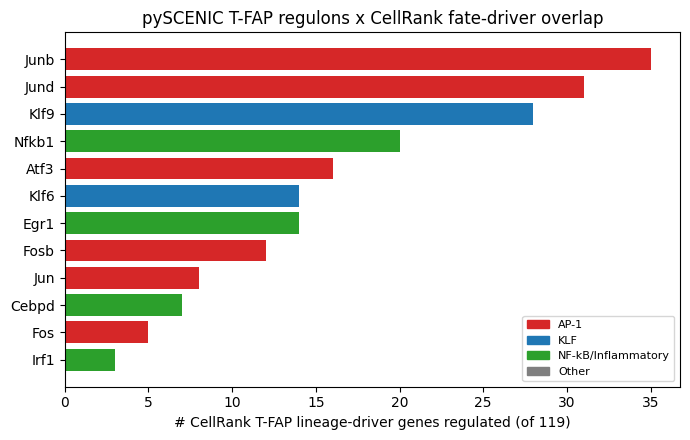

In [6]:
fam_colors = {'AP-1': '#d62728', 'KLF': '#1f77b4', 'NF-kB/Inflammatory': '#2ca02c', 'Other': '#7f7f7f'}
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = shared[shared['n_cellrank_drivers'] > 0].sort_values('n_cellrank_drivers')
ax.barh(plot_df['TF'], plot_df['n_cellrank_drivers'], color=[fam_colors[f] for f in plot_df['family']])
ax.set_xlabel('# CellRank T-FAP lineage-driver genes regulated (of 119)')
ax.set_title('pySCENIC T-FAP regulons x CellRank fate-driver overlap')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in fam_colors.values()]
ax.legend(handles, fam_colors.keys(), loc='lower right', fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / 'tf_cellrank_driver_counts.png', dpi=150)
plt.show()

Junb and Jund alone account for 35 and 31 of the 119 CellRank T-FAP driver genes respectively — more than double any other regulon. Combined with Klf9 (28) these three regulons anchor most of the mechanism-informed feature set that Stage 7 will draw from. The three "Other" TFs (Pbx1, Prdm16, Zfp369) contribute **zero** CellRank driver genes despite being differentially active — they are markers of the T-FAP transcriptional state but not drivers of the fate-commitment program CellRank recovers, so they are deprioritised as Stage 7 candidate features.

## 5. Final per-TF synthesis table

In [7]:
receptor_hits = (feedback[feedback['regulated_by_TFAP_TF'] != '']
                  .assign(tf=lambda d: d['regulated_by_TFAP_TF'].str.split(', '))
                  .explode('tf')
                  .groupby('tf')['receptor_gene'].apply(lambda s: ', '.join(sorted(set(s)))))
shared['receptor_feedback_targets'] = shared['TF'].map(lambda tf: receptor_hits.get(tf, ''))
shared['upstream_signal_family'] = shared['family'].map(UPSTREAM)

synthesis_cols = ['TF', 'family', 'upstream_signal_family', 'harvey_score', 'cherief_score',
                   'n_union_targets', 'n_cross_dataset_targets', 'n_cellrank_drivers',
                   'top_cellrank_drivers', 'receptor_feedback_targets']
synthesis = shared[synthesis_cols].sort_values('n_cellrank_drivers', ascending=False)
synthesis.to_csv(OUT_DATA / 'tf_signal_target_synthesis.csv', index=False)
synthesis

,TF,family,upstream_signal_family,harvey_score,cherief_score,n_union_targets,n_cross_dataset_targets,n_cellrank_drivers,top_cellrank_drivers,receptor_feedback_targets
5,Junb,AP-1,TGFb / PDGF -> MEK-ERK,17.365800,27.267511,413,30,35,"Gdf10, Angptl4, Il6",
3,Jund,AP-1,TGFb / PDGF -> MEK-ERK,18.148964,28.431025,228,2,31,"Selenop, Serpina3n, Cst3",Pdgfra
10,Klf9,KLF,Mechanotransduction / TGFb,9.250983,24.289484,551,17,28,"Gdf10, Icam1, Nfib","Nrp2, Pdgfra"
7,Nfkb1,NF-kB/Inflammatory,TNF / IL-1 / Macrophage-Notch,15.078421,21.235260,469,38,20,"Ptx3, Cebpb, Fosb",
9,Atf3,AP-1,TGFb / PDGF -> MEK-ERK,11.003265,25.695847,324,6,16,"Junb, Cebpd, Fosb",
13,Klf6,KLF,Mechanotransduction / TGFb,4.943580,18.595524,373,3,14,"Slc16a1, Zfp36l1, Socs3",
1,Egr1,NF-kB/Inflammatory,TNF / IL-1 / Macrophage-Notch,20.603586,25.893581,903,21,14,"Steap4, Id2, Pltp","Nrp1, Nrp2, Pdgfra"
4,Fosb,AP-1,TGFb / PDGF -> MEK-ERK,17.838593,26.718578,603,10,12,"Sfrp1, Emb, Sgk1",Pdgfra
6,Jun,AP-1,TGFb / PDGF -> MEK-ERK,16.775726,26.297634,49,1,8,"Cxcl12, Slc1a3, Sfrp2",
0,Cebpd,NF-kB/Inflammatory,TNF / IL-1 / Macrophage-Notch,20.779316,29.314266,30,0,7,"Lpl, Id3, Cebpb",


## 6. Regulatory circuit diagram

Three layers: literature-bridged upstream signal family → T-FAP TF regulon (sized/coloured by family) → the 119-gene CellRank T-FAP fate program. The orange dashed edges highlight the Section 3 finding: six of the regulons (Egr1, Irf1, Jund, Fosb, Fos, Klf9) also target `Pdgfra`, the receptor for the strongest innervated growth-factor signal lost upon denervation — a candidate mechanism by which the fibrotic TF program could uncouple T-FAPs from the regenerative niche cue, alongside its role as the compartment marker gene (see caveat above).

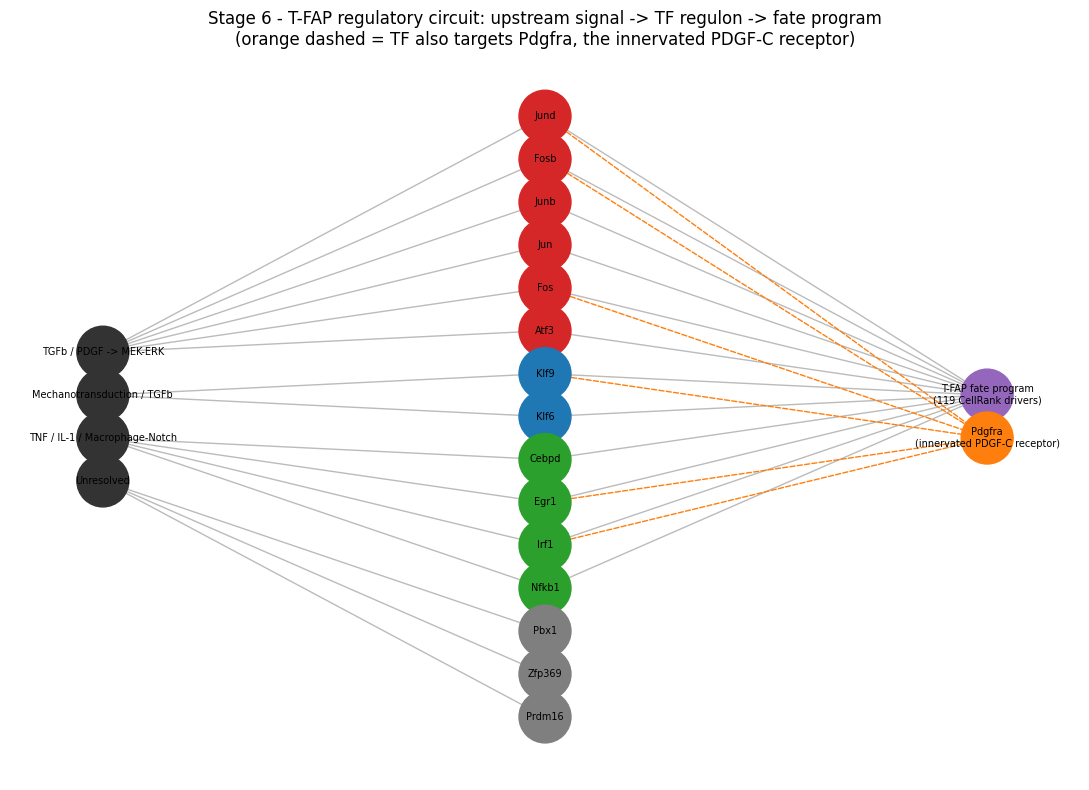

In [8]:
G = nx.DiGraph()
for fam in UPSTREAM:
    G.add_node(UPSTREAM[fam], layer=0, kind='signal')

family_order = {'AP-1': 0, 'KLF': 1, 'NF-kB/Inflammatory': 2, 'Other': 3}
shared_by_family = shared.iloc[shared['family'].map(family_order).argsort(kind='stable')]
for _, r in shared_by_family.iterrows():
    G.add_node(r['TF'], layer=1, kind='tf', family=r['family'])
    G.add_edge(UPSTREAM[r['family']], r['TF'])

G.add_node('T-FAP fate program\n(119 CellRank drivers)', layer=2, kind='program')
for _, r in shared.iterrows():
    if r['n_cellrank_drivers'] > 0:
        G.add_edge(r['TF'], 'T-FAP fate program\n(119 CellRank drivers)', weight=r['n_cellrank_drivers'])

G.add_node('Pdgfra\n(innervated PDGF-C receptor)', layer=2, kind='feedback')
for tf in ['Egr1', 'Irf1', 'Jund', 'Fosb', 'Fos', 'Klf9']:
    G.add_edge(tf, 'Pdgfra\n(innervated PDGF-C receptor)', weight=1, style='feedback')

layer_x = {0: 0, 1: 1, 2: 2}
pos = {}
for layer in (0, 1, 2):
    nodes = [n for n, d in G.nodes(data=True) if d['layer'] == layer]
    for i, n in enumerate(nodes):
        pos[n] = (layer_x[layer], -(i - (len(nodes) - 1) / 2))

fig, ax = plt.subplots(figsize=(11, 8))
node_colors = []
for n, d in G.nodes(data=True):
    if d['kind'] == 'signal':
        node_colors.append('#333333')
    elif d['kind'] == 'tf':
        node_colors.append(fam_colors[d['family']])
    elif d['kind'] == 'feedback':
        node_colors.append('#ff7f0e')
    else:
        node_colors.append('#9467bd')

normal_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('style') != 'feedback']
feedback_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('style') == 'feedback']
nx.draw_networkx_edges(G, pos, edgelist=normal_edges, ax=ax, edge_color='#bbbbbb', arrows=True, arrowsize=8)
nx.draw_networkx_edges(G, pos, edgelist=feedback_edges, ax=ax, edge_color='#ff7f0e', style='dashed', arrows=True, arrowsize=8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1400)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
ax.set_title('Stage 6 - T-FAP regulatory circuit: upstream signal -> TF regulon -> fate program\n(orange dashed = TF also targets Pdgfra, the innervated PDGF-C receptor)')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUT_FIG / 'regulatory_circuit.png', dpi=150)
plt.show()

## 7. Summary for Stage 7

- **Innervated -> TSPC fate:** PDGF-C/Wnt5a/BMP3/Sema3c niche signals (LIANA) maintain a progenitor pool biased toward TSPC (CellRank: 82.6% TSPC fate probability). Their receptors (Pdgfra, Fzd4, Nrp1/2, Plxna1/2) are, in several cases, themselves targets of the AP-1/KLF/NF-κB T-FAP program — consistent with the T-FAP program actively reshaping the cell's receptivity to the regenerative niche, not just responding downstream of it.
- **Denervated -> T-FAP fate:** loss of those signals plus gain of TNF/Notch, Sema3f, and laminin-integrin signalling (LIANA) accompanies a rise in T-FAP fate probability (17.2% -> 28.9%, CellRank) and induction of the same AP-1/KLF/NF-κB regulons (pySCENIC), which in turn drive 119 T-FAP lineage-driver genes (CellRank), dominated by Junb/Jund/Klf9 targets (Section 4).
- **Feature set for Stage 7:** prioritise the 119-gene CellRank x pySCENIC overlap, weighted toward Junb/Jund/Klf9 targets (`data/mechanistic_synthesis/tf_signal_target_synthesis.csv`), plus TSPC identity markers (Tppp3, Prg4, Igfbp6, Sema3c, Cd34). Deprioritise Pbx1/Prdm16/Zfp369-only targets — differentially active but contribute no CellRank fate-driver genes.
- **Caveats carried forward:** (1) cross-dataset target-gene identity is inconsistent even where TF activity is consistent — treat individual TF-target edges as dataset-specific hypotheses, not confirmed circuitry; (2) the Pdgfra feedback finding is confounded by its role as the compartment marker gene; (3) signal-to-TF-family links (TNF->NF-κB, TGFβ->AP-1, PDGF->MEK-ERK->AP-1) remain literature-bridged, not directly tested — the raw GRNBoost2 adjacency tables needed to test this quantitatively exist only on HPC scratch and were not pulled into this repo.